# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
2279,11,99,"(0.43, 0.6)","(-0.002, -0.194, 0.024, 0.451)",1,1.0,"(-0.006, 0.002, 0.033, 0.138)",1.0,1.0,"(-0.006, 0.198, 0.036, -0.172)"
770,33,33,"(0.03, 0.9)","(-0.124, -0.572, 0.17, 0.71)",0,1.0,"(-0.135, -0.761, 0.184, 0.891)",0.0,1.0,"(-0.151, -0.951, 0.202, 1.073)"
1878,11,80,"(0.99, 1.2)","(0.034, 0.553, -0.097, -1.227)",0,1.0,"(0.045, 0.357, -0.121, -0.921)",1.0,1.0,"(0.052, 0.556, -0.14, -1.302)"
2165,2,95,"(0.51, 0.0)","(0.002, 0.042, -0.02, -0.037)",0,1.0,"(0.003, -0.158, -0.02, 0.372)",0.0,1.0,"(-0.001, -0.358, -0.013, 0.781)"
309,20,14,"(0.93, 1.1)","(0.09, 0.381, -0.063, -0.646)",1,1.0,"(0.098, 0.579, -0.076, -1.004)",0.0,1.0,"(0.109, 0.383, -0.096, -0.697)"
...,...,...,...,...,...,...,...,...,...,...
758,21,33,"(0.03, 0.9)","(-0.026, -0.562, 0.061, 0.5)",1,1.0,"(-0.037, -0.374, 0.071, 0.355)",1.0,1.0,"(-0.045, -0.186, 0.079, 0.213)"
1666,32,70,"(0.22, 1.9)","(0.093, 0.4, -0.063, -0.256)",1,1.0,"(0.101, 0.586, -0.068, -0.346)",1.0,1.0,"(0.113, 0.772, -0.075, -0.437)"
177,6,7,"(0.07, 1.8)","(0.043, 0.41, 0.014, -0.175)",0,1.0,"(0.051, 0.225, 0.01, -0.094)",0.0,1.0,"(0.056, 0.039, 0.008, -0.014)"
447,28,21,"(0.37, 1.9)","(0.19, 0.757, -0.081, -0.463)",0,1.0,"(0.205, 0.571, -0.09, -0.375)",0.0,1.0,"(0.217, 0.385, -0.098, -0.289)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.17222824692726135, 2.1684839725494385]","[0.16645482182502747, 2.198817491531372]","[0.0683121457695961, 0.42011120915412903, 0.03...",1.900698,1.788551,0.147984
1,1,"[0.1751156449317932, 2.167196035385132]","[0.16922053694725037, 2.1975226402282715]","[0.06617483496665955, 0.4164864420890808, 0.03...",1.899796,1.773830,0.148183
2,2,"[0.17806406319141388, 2.165938377380371]","[0.17204757034778595, 2.1962532997131348]","[0.06408151984214783, 0.4129062294960022, 0.03...",1.898924,1.759286,0.148387
3,3,"[0.1810874044895172, 2.1647651195526123]","[0.17495258152484894, 2.195064067840576]","[0.062034692615270615, 0.40937018394470215, 0....",1.898090,1.744916,0.148594
4,4,"[0.18417885899543762, 2.163640260696411]","[0.17792721092700958, 2.193920373916626]","[0.06003965437412262, 0.40587037801742554, 0.0...",1.897290,1.730710,0.148798


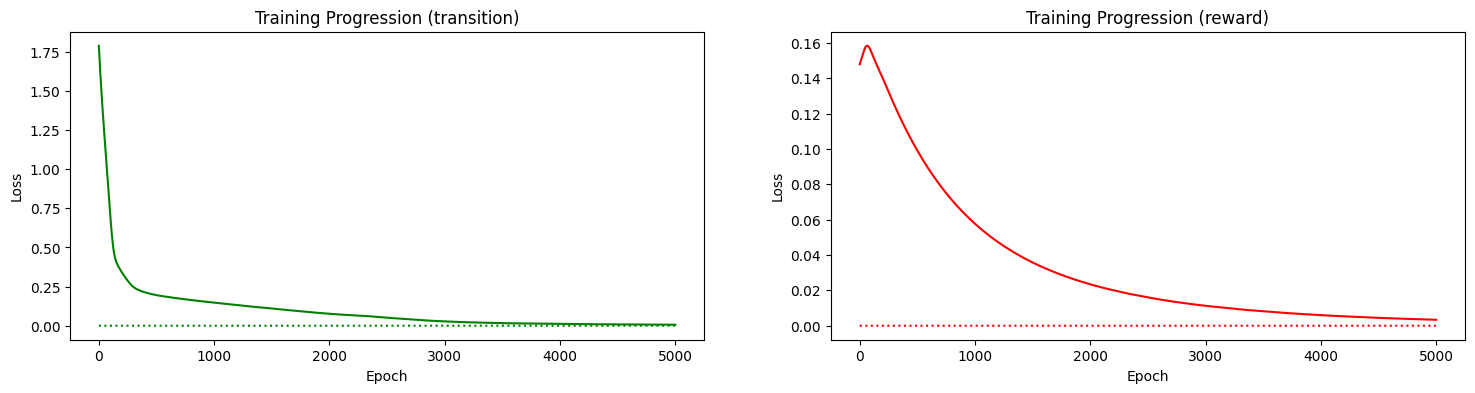

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

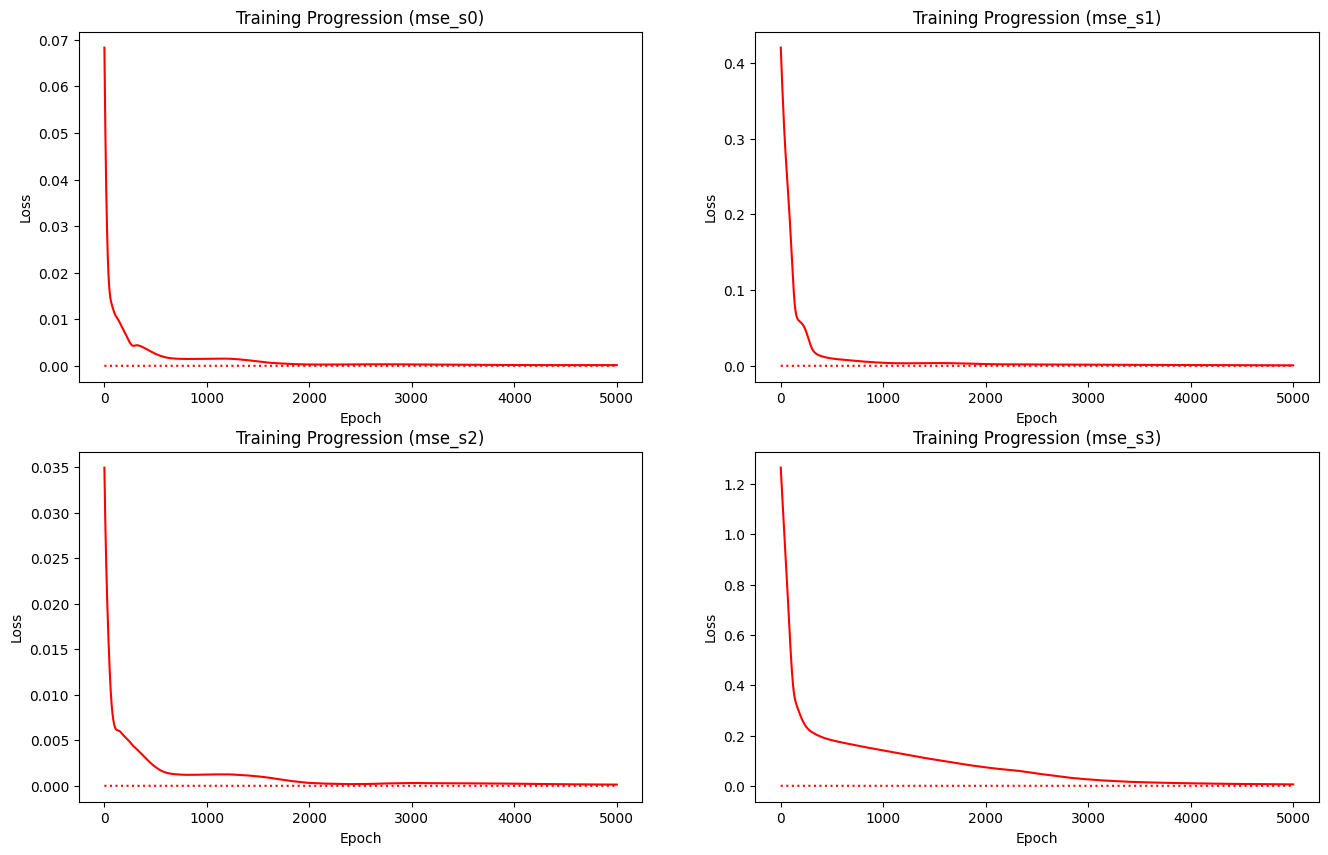

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

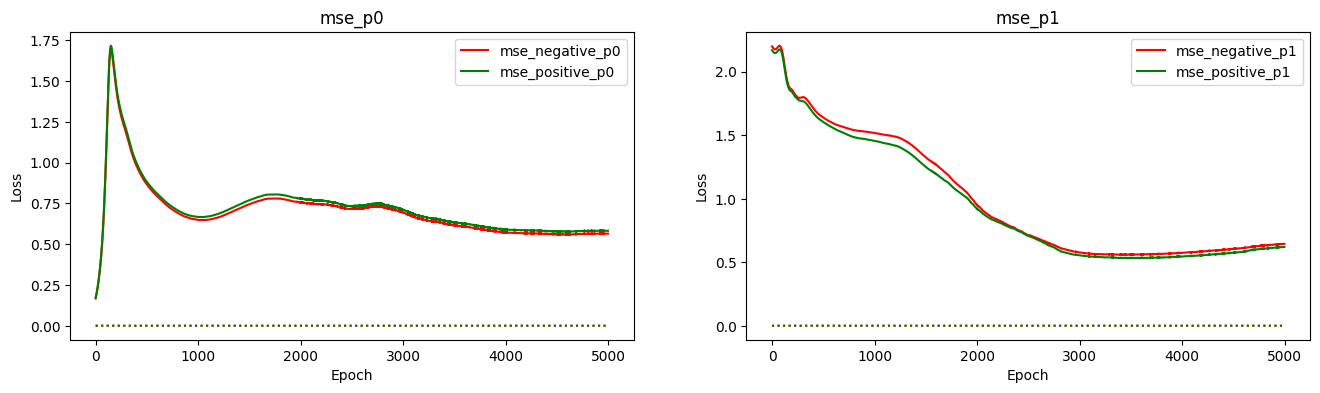

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, train_data['regularize'], 'r')
axs.set_title(f'mse_p{i}')
axs.legend()

plt.show()

# Evaluation

In [ ]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)","(-0.016, -0.044, -0.012, -0.023)","(-0.125, 0.499)",0.9
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)","(-0.015, 0.14, -0.012, -0.206)","(-0.144, 0.878)",0.9
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)","(-0.01, 0.336, -0.016, -0.402)","(-0.214, 0.904)",0.9
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)","(0.0, 0.53, -0.025, -0.608)","(-0.287, 0.932)",0.9
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)","(0.016, 0.723, -0.039, -0.82)","(-0.361, 0.961)",0.9


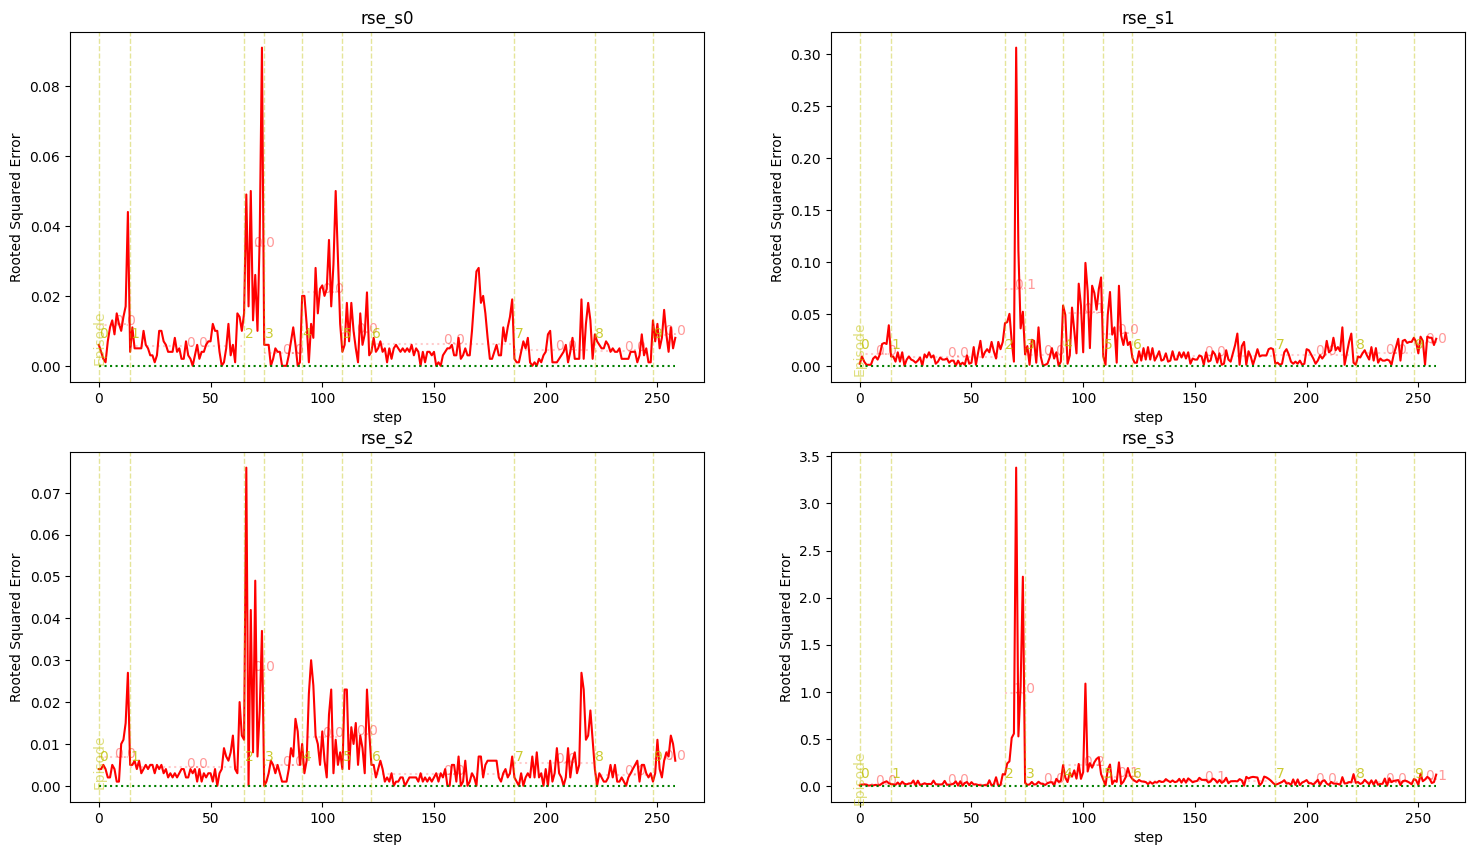

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

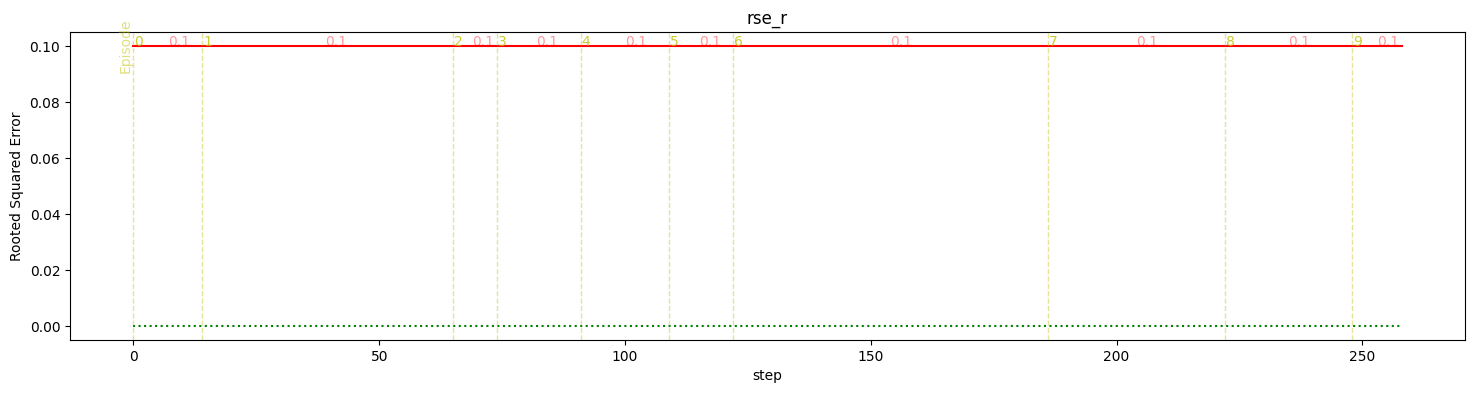

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

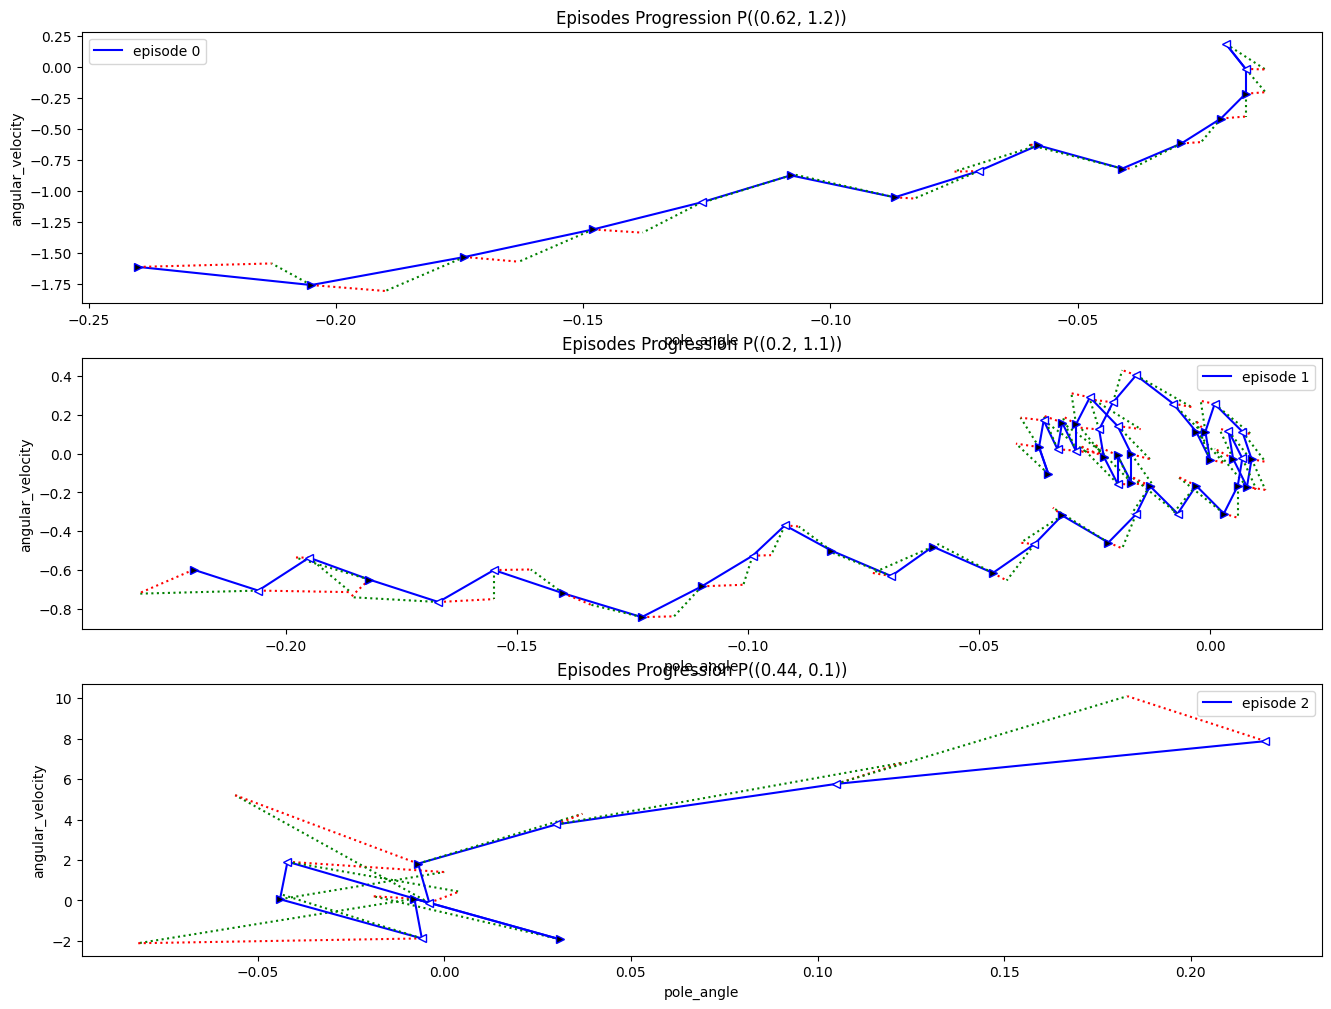

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()